   age  gender  wbc_count  rbc_count  hemoglobin  platelet_count  \
0   52  Female      19.61       3.75       10.64           281.2   
1   15  Female      17.49       1.78       12.26           265.3   
2   72    Male      39.63       2.62        8.34           110.4   
3   61  Female      23.96       4.96        9.69           216.6   
4   21    Male      13.98       4.99       13.17            92.6   

   blast_cells_percent  lymphocyte_percent  neutrophil_percent  \
0                 6.54               60.27               69.56   
1                31.80               18.07                7.89   
2                 0.00               45.87               73.07   
3                20.39               39.00               77.73   
4                 0.91               40.28               43.96   

   bone_marrow_blast_percent  spleen_enlarged  lymph_node_swelling  fatigue  \
0                      25.12                0                    0        0   
1                      43.95        

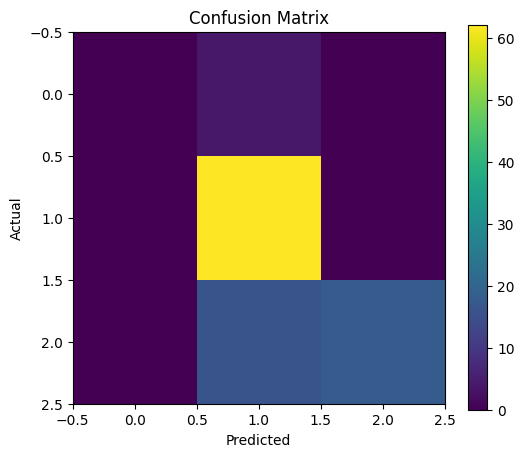


Classification Report:
              precision    recall  f1-score   support

    Leukemia       0.00      0.00      0.00         4
    Lymphoma       0.76      1.00      0.86        62
   No Cancer       1.00      0.53      0.69        34

    accuracy                           0.80       100
   macro avg       0.59      0.51      0.52       100
weighted avg       0.81      0.80      0.77       100


Feature Importance:
                      Feature  Importance
9   bone_marrow_blast_percent    0.136123
2                   wbc_count    0.113567
11        lymph_node_swelling    0.112875
14                weight_loss    0.085598
6         blast_cells_percent    0.085104
13                      fever    0.065557
5              platelet_count    0.064156
12                    fatigue    0.062518
8          neutrophil_percent    0.052049
3                   rbc_count    0.048240
7          lymphocyte_percent    0.047317
10            spleen_enlarged    0.041502
4                  hemoglobi

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


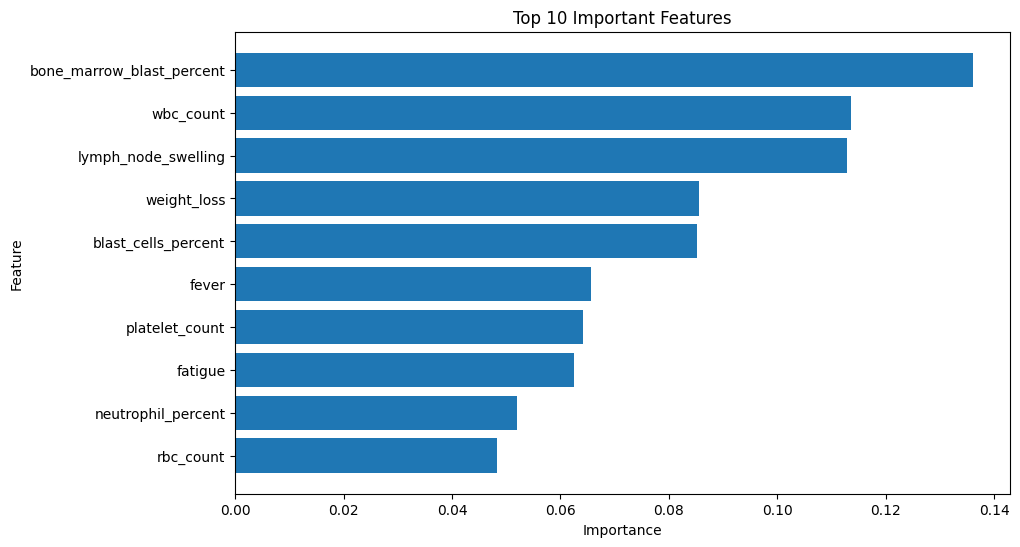

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)




df = pd.read_csv("/content/blood_cancer.csv")



print(df.head())

print("\nShape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDiagnosis:")
print(df["diagnosis"].value_counts())




le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])


X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]




X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    max_features="sqrt",
    oob_score=True,
    random_state=42
)



rf.fit(X_train, y_train)



y_pred = rf.predict(X_test)



accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)



print("OOB Score:", rf.oob_score_)


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()



print("\nClassification Report:")
print(classification_report(y_test, y_pred))




importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)



top10 = importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()